### 0. Read the data after cleaning based on mutual information.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from feature_importance_sorter import FeatureImportanceSorter

DATA_DIR = Path('..') / 'data'
N_RUNS = 20

X_train = pd.read_csv(DATA_DIR / 'x_train_scaled_reduced_after_mi.csv')
y_train = np.loadtxt(DATA_DIR / 'y_train.txt', skiprows=1).astype(int)

feature_names = X_train.columns.tolist()
X = X_train.to_numpy()

print(f'X_train: {X_train.shape}   features: {len(feature_names)}')
print(f'y_train: {y_train.shape}   positive rate: {y_train.mean():.3f}')
print(f'Default runs per model: {N_RUNS}')

X_train: (5000, 493)   features: 493
y_train: (5000,)   positive rate: 0.498
Default runs per model: 20


In [2]:
MODEL_LABELS = {
    'rf': 'Random Forest',
    'extra': 'ExtraTrees',
    'lgbm': 'LightGBM',
    'xgb': 'XGBoost',
}


def run_model_study(
    model_type: str,
    n_runs: int = N_RUNS,
    top_n: int = 25,
    n_splits: int = 5,
):
    """Run CV importance study, save CSVs, print summary tables, and plot top features."""
    if model_type not in MODEL_LABELS:
        raise ValueError(
            f"Unknown model_type '{model_type}'. Choose from: {list(MODEL_LABELS)}"
        )

    label = MODEL_LABELS[model_type]
    print(f'=== {label} ({model_type}) — {n_runs} runs, {n_splits}-fold CV ===')

    score_rows = []
    importance_rows = []
    log_every = max(1, n_runs // 10)

    for run in range(n_runs):
        sorter = FeatureImportanceSorter(random_seed=run)
        ranking, summary, params = sorter.get_ranking(
            X,
            y_train,
            feature_names=feature_names,
            model_type=model_type,
            random_config=(run > 0),
            n_splits=n_splits,
        )

        score_row = {
            'run_id': run,
            'random_seed': summary['random_seed'],
            'model_type': summary['model_type'],
            'config_type': summary['config_type'],
        }
        for metric in ('acc', 'prec', 'rec', 'f1', 'tp', 'fp'):
            score_row[f'{metric}_mean'] = summary[metric]['mean']
            score_row[f'{metric}_std'] = summary[metric]['std']
        for key, value in params.items():
            score_row[f'param_{key}'] = value
        score_rows.append(score_row)

        run_importance = ranking[['feature_name', 'importance']].copy()
        run_importance.insert(0, 'run_id', run)
        importance_rows.append(run_importance)

        if (run + 1) % log_every == 0 or (run + 1) == n_runs:
            print(f'Completed {run + 1}/{n_runs} runs')

    scores_df = pd.DataFrame(score_rows)
    importance_long_df = pd.concat(importance_rows, ignore_index=True)

    importance_summary = (
        importance_long_df
        .groupby('feature_name', as_index=False)
        .agg(
            importance_mean=('importance', 'mean'),
            importance_std=('importance', 'std'),
        )
        .sort_values('importance_mean', ascending=False)
        .reset_index(drop=True)
    )
    importance_summary['rank'] = np.arange(1, len(importance_summary) + 1)

    out_dir = DATA_DIR / f'{model_type}_feature_importance'
    out_dir.mkdir(parents=True, exist_ok=True)

    scores_path = out_dir / f'{model_type}_model_scores_mi_reduced.csv'
    importance_path = out_dir / f'{model_type}_model_feature_importance_mi_reduced.csv'

    scores_df.to_csv(scores_path, index=False)
    importance_long_df.to_csv(importance_path, index=False)

    print(f'Saved scores:     {scores_path}  ({len(scores_df)} runs)')
    print(f'Saved importance: {importance_path}  ({len(importance_long_df)} rows)')
    print(f'Scores shape: {scores_df.shape}, importance shape: {importance_long_df.shape}')

    print('\nRun scores (first 5):')
    display(scores_df.head())

    print('\nTop 20 features by mean importance:')
    display(importance_summary.head(20))

    plot_df = importance_summary.head(top_n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 10))
    ax.barh(
        plot_df['feature_name'],
        plot_df['importance_mean'],
        xerr=plot_df['importance_std'],
        color='#4e79a7',
        ecolor='#333333',
        capsize=2,
    )
    ax.set_xlabel(f'Mean feature importance ({n_runs} {label} runs, {n_splits}-fold CV each)')
    ax.set_title(f'Top {top_n} features — {label} — MI-reduced dataset')
    plt.tight_layout()
    plt.show()

    return scores_df, importance_long_df, importance_summary

The first run is the default model provided by the model's package.

### 1. Assess the feature importances using different configurations of Random Forest

In [ ]:
rf_scores, rf_importance_long, rf_summary = run_model_study('rf', N_RUNS)

### 2. Assess the feature importances using different configurations of ExtraTrees

=== ExtraTrees (extra) — 20 runs, 5-fold CV ===
Completed 2/20 runs
Completed 4/20 runs
Completed 6/20 runs
Completed 8/20 runs
Completed 10/20 runs
Completed 12/20 runs
Completed 14/20 runs
Completed 16/20 runs
Completed 18/20 runs
Completed 20/20 runs
Saved scores:     ../data/extra_feature_importance/extra_model_scores_mi_reduced.csv  (20 runs)
Saved importance: ../data/extra_feature_importance/extra_model_feature_importance_mi_reduced.csv  (9860 rows)
Scores shape: (20, 22), importance shape: (9860, 3)

Run scores (first 5):


,run_id,random_seed,model_type,config_type,acc_mean,acc_std,prec_mean,prec_std,rec_mean,rec_std,...,tp_mean,tp_std,fp_mean,fp_std,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_criterion,param_class_weight
0,0,0,extra,default,0.5624,0.009351,0.568943,0.010324,0.497586,0.020719,...,247.6,10.346014,187.6,8.731552,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,extra,random,0.5950,0.013327,0.626703,0.015828,0.459829,0.024672,...,228.8,12.073111,136.2,7.110556,87.0,4.0,5.0,9.0,gini,None
2,2,2,extra,random,0.6066,0.013836,0.615165,0.015144,0.559499,0.018017,...,278.4,8.754427,174.2,8.471127,218.0,NaN,9.0,9.0,gini,balanced
3,3,3,extra,random,0.6172,0.026671,0.662062,0.038829,0.471436,0.028673,...,234.6,14.485855,119.8,14.302447,412.0,5.0,2.0,4.0,gini,None
4,4,4,extra,random,0.6148,0.013775,0.638161,0.014119,0.520912,0.022355,...,259.2,10.998182,146.8,3.544009,172.0,5.0,8.0,8.0,entropy,balanced



Top 20 features by mean importance:


,feature_name,importance_mean,importance_std,rank
0,V176,0.017054,0.007877,1
1,V255,0.016531,0.010264,2
2,V191,0.015866,0.007862,3
3,V224,0.014405,0.007488,4
4,V215,0.013755,0.008570,5
5,V11,0.012870,0.007519,6
6,V483,0.012081,0.006069,7
7,V342,0.011717,0.005969,8
8,V380,0.011669,0.006818,9
9,V161,0.011462,0.005910,10


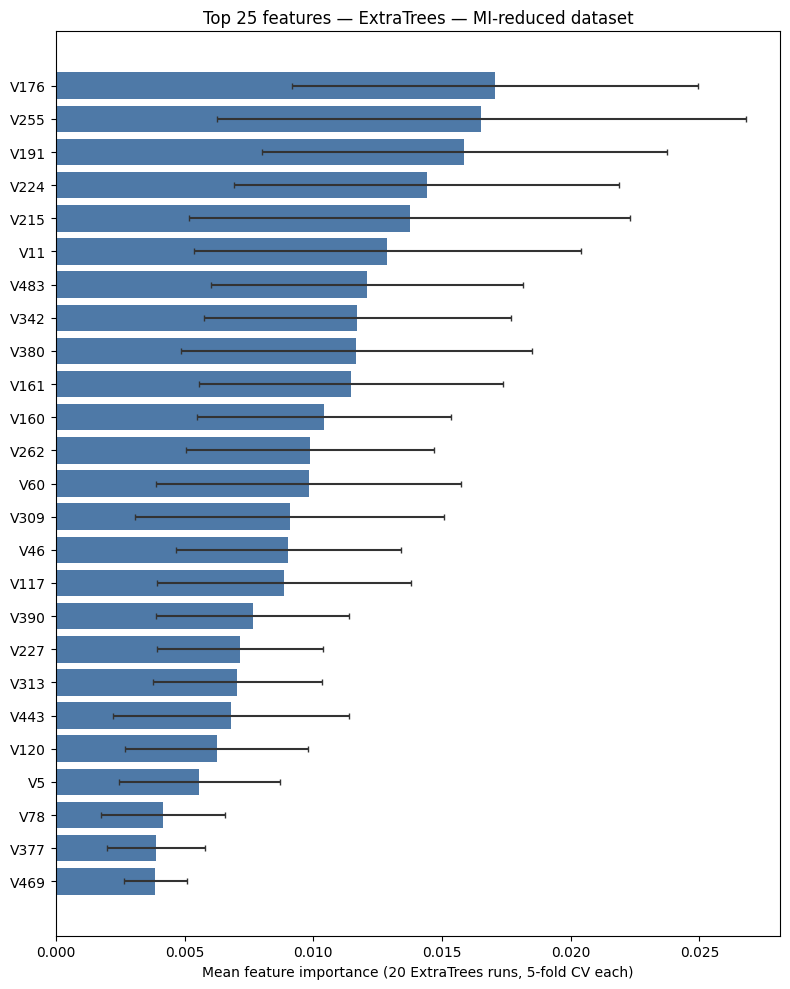

In [5]:
extra_scores, extra_importance_long, extra_summary = run_model_study('extra', N_RUNS)

### 3. Assess the feature importances using different configurations of LightGBM

=== LightGBM (lgbm) — 20 runs, 5-fold CV ===
Completed 2/20 runs
Completed 4/20 runs
Completed 6/20 runs
Completed 8/20 runs
Completed 10/20 runs
Completed 12/20 runs
Completed 14/20 runs
Completed 16/20 runs
Completed 18/20 runs
Completed 20/20 runs
Saved scores:     ../data/lgbm_feature_importance/lgbm_model_scores_mi_reduced.csv  (20 runs)
Saved importance: ../data/lgbm_feature_importance/lgbm_model_feature_importance_mi_reduced.csv  (9860 rows)
Scores shape: (20, 25), importance shape: (9860, 3)

Run scores (first 5):


,run_id,random_seed,model_type,config_type,acc_mean,acc_std,prec_mean,prec_std,rec_mean,rec_std,...,fp_std,param_n_estimators,param_learning_rate,param_num_leaves,param_min_child_samples,param_colsample_bytree,param_reg_alpha,param_reg_lambda,param_boosting_type,param_class_weight
0,0,0,lgbm,default,0.6648,0.014358,0.662901,0.016791,0.665194,0.014532,...,12.970736,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,lgbm,random,0.6422,0.012238,0.641417,0.015378,0.638263,0.010663,...,11.651609,87.0,0.309155,92.0,19.0,0.651166,0.146756,0.684677,gbdt,balanced
2,2,2,lgbm,random,0.6606,0.016268,0.658870,0.017469,0.659980,0.016884,...,11.496086,218.0,0.065525,92.0,32.0,0.973865,0.484749,1.141073,gbdt,balanced
3,3,3,lgbm,random,0.6822,0.010206,0.683023,0.012939,0.674842,0.009188,...,9.402127,412.0,0.031217,23.0,66.0,0.560664,0.569311,1.374124,gbdt,balanced
4,4,4,lgbm,random,0.6496,0.008570,0.647501,0.009407,0.649933,0.019962,...,9.785704,172.0,0.280186,89.0,11.0,0.927810,0.609036,1.695112,gbdt,None



Top 20 features by mean importance:


,feature_name,importance_mean,importance_std,rank
0,V255,192.06,166.651608,1
1,V215,191.60,164.068933,2
2,V380,185.33,154.428212,3
3,V342,180.23,146.877912,4
4,V176,173.75,145.065863,5
5,V191,169.35,131.723472,6
6,V160,156.43,134.613822,7
7,V117,153.39,131.092374,8
8,V227,125.07,96.078505,9
9,V390,113.97,81.197025,10


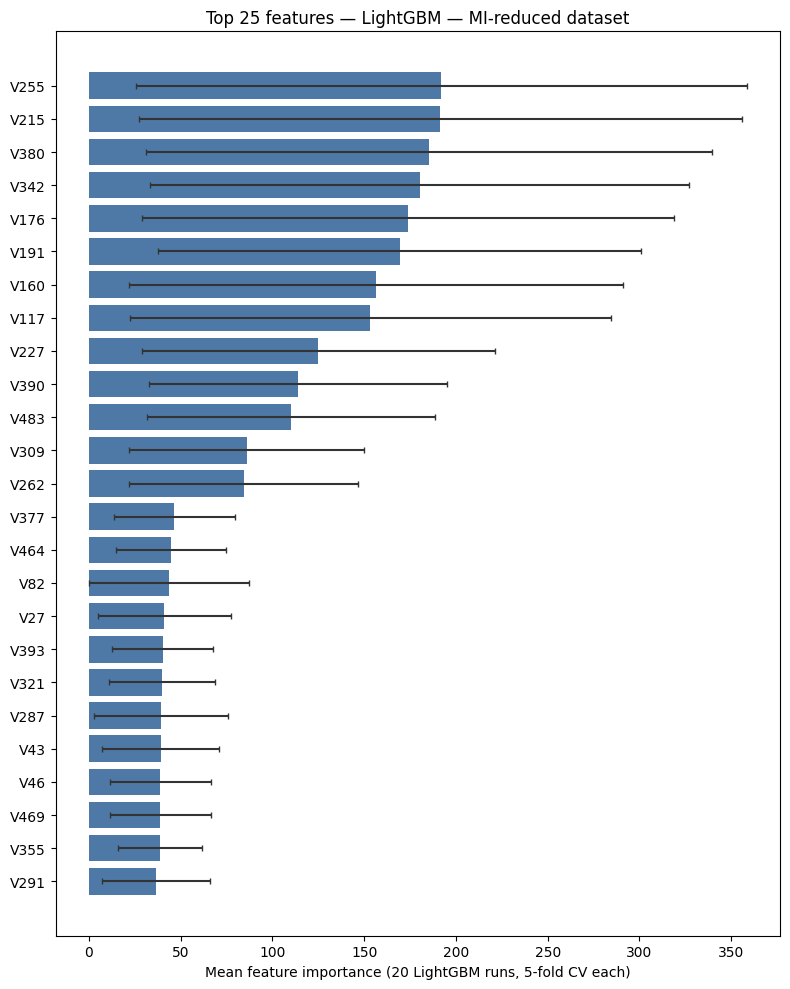

In [4]:
lgbm_scores, lgbm_importance_long, lgbm_summary = run_model_study('lgbm', N_RUNS)

### 4. Assess the feature importances using different configurations of XGBoost

=== XGBoost (xgb) — 20 runs, 5-fold CV ===
Completed 2/20 runs
Completed 4/20 runs
Completed 6/20 runs
Completed 8/20 runs
Completed 10/20 runs
Completed 12/20 runs
Completed 14/20 runs
Completed 16/20 runs
Completed 18/20 runs
Completed 20/20 runs
Saved scores:     ../data/xgb_feature_importance/xgb_model_scores_mi_reduced.csv  (20 runs)
Saved importance: ../data/xgb_feature_importance/xgb_model_feature_importance_mi_reduced.csv  (9860 rows)
Scores shape: (20, 24), importance shape: (9860, 3)

Run scores (first 5):


,run_id,random_seed,model_type,config_type,acc_mean,acc_std,prec_mean,prec_std,rec_mean,rec_std,...,fp_mean,fp_std,param_n_estimators,param_learning_rate,param_max_depth,param_subsample,param_colsample_bytree,param_min_child_weight,param_reg_alpha,param_reg_lambda
0,0,0,xgb,default,0.6460,0.014170,0.649393,0.017521,0.628208,0.017989,...,169.0,12.083046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,xgb,random,0.6194,0.002059,0.621453,0.006356,0.602492,0.016326,...,182.8,9.806121,87.0,0.309155,3.0,0.500057,0.651166,1.0,0.092339,0.872520
2,2,2,xgb,random,0.6838,0.008304,0.696065,0.012986,0.647914,0.015228,...,141.0,9.979980,218.0,0.065525,3.0,0.774831,0.717661,9.0,0.320536,0.808853
3,3,3,xgb,random,0.6634,0.010190,0.666997,0.013101,0.646704,0.008649,...,160.8,8.840814,412.0,0.031217,6.0,0.645452,0.755414,4.0,0.896293,0.751171
4,4,4,xgb,random,0.6472,0.015510,0.649087,0.017683,0.634656,0.020128,...,171.0,13.401492,172.0,0.280186,8.0,0.986342,0.857408,3.0,0.597556,0.782928



Top 20 features by mean importance:


,feature_name,importance_mean,importance_std,rank
0,V11,0.005914,0.001337,1
1,V160,0.005276,0.000715,2
2,V255,0.005255,0.000824,3
3,V176,0.005157,0.000735,4
4,V191,0.004849,0.000561,5
5,V215,0.004515,0.000647,6
6,V380,0.004418,0.000566,7
7,V224,0.004305,0.001289,8
8,V342,0.004269,0.000570,9
9,V117,0.004246,0.000496,10


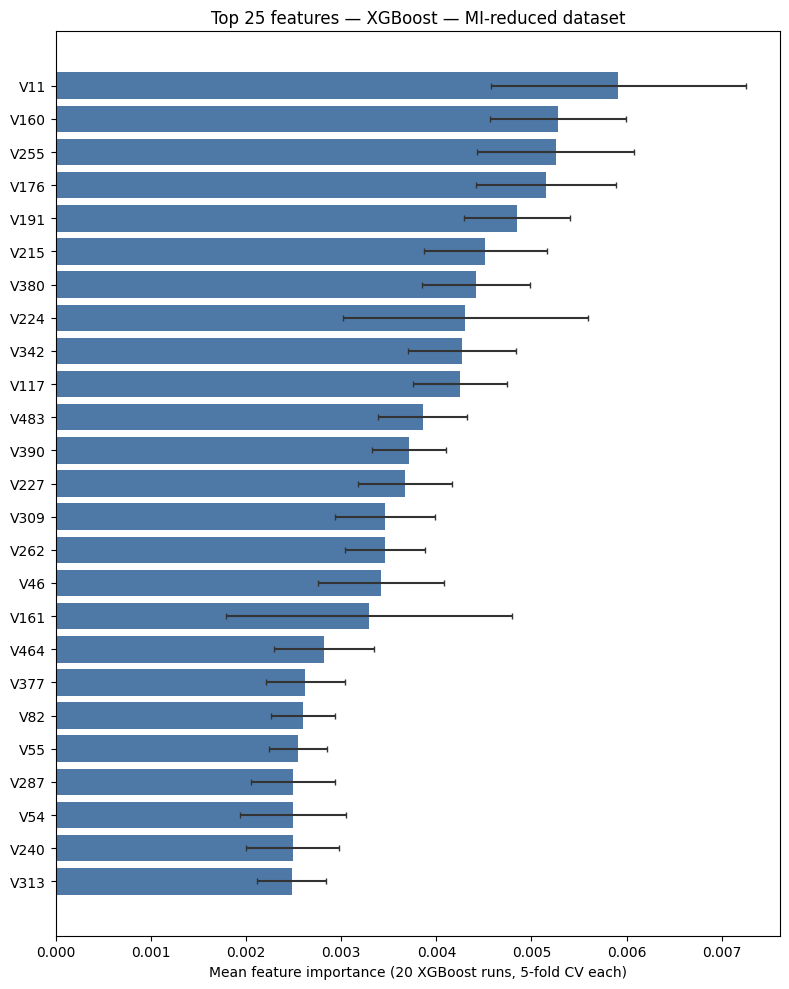

In [3]:
xgb_scores, xgb_importance_long, xgb_summary = run_model_study('xgb', N_RUNS)